# Global Disaster Risk Analysis at the Country Level

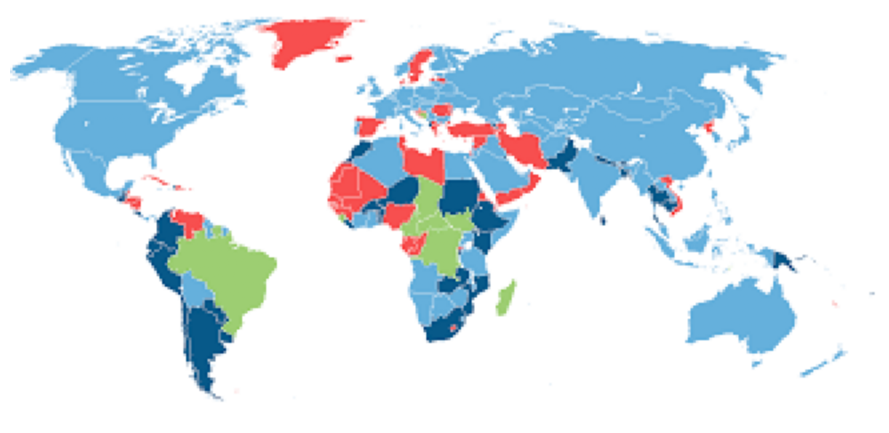

In [78]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
img_path = r"C:\Users\LOQ\Downloads\images.png"
img = mpimg.imread(img_path)

plt.figure(figsize=(9,7))  
plt.imshow(img)
plt.axis('off') 
plt.tight_layout()
plt.show()


* The dataset is the EM-DAT Global Disaster Database (1900–2021). It contains historical records of natural and technological disasters around the world. Each record provides information about a specific disaster, including: Country – where the disaster occurred Year / Date – when it happened Disaster Type – e.g., earthquake, flood, drought, epidemic, storm Impact – number of deaths, number of people affected, and economic losses Duration – how long the disaster lasted This dataset is used by organizations like the UN, WHO, and World Bank to study patterns of disasters and assess the vulnerability of countries. In this project, we will use this dataset to analysis patterns of disasters .

# 1️⃣ Import Libraries

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#  2️⃣ Load the Dataset

In [80]:
df = pd.read_csv("1900_2021_DISASTERS.xlsx - emdat data.csv")

# 3️⃣ First Look at the Data

In [81]:
df.head()

,Year,Seq,Glide,Disaster Group,Disaster Subgroup,Disaster Type,Disaster Subtype,Disaster Subsubtype,Event Name,Country,...,No Affected,No Homeless,Total Affected,Insured Damages ('000 US$),Total Damages ('000 US$),CPI,Adm Level,Admin1 Code,Admin2 Code,Geo Locations
0,1900,9002,NaN,Natural,Climatological,Drought,Drought,NaN,NaN,Cabo Verde,...,NaN,NaN,NaN,NaN,NaN,3.221647,NaN,NaN,NaN,NaN
1,1900,9001,NaN,Natural,Climatological,Drought,Drought,NaN,NaN,India,...,NaN,NaN,NaN,NaN,NaN,3.221647,NaN,NaN,NaN,NaN
2,1902,12,NaN,Natural,Geophysical,Earthquake,Ground movement,NaN,NaN,Guatemala,...,NaN,NaN,NaN,NaN,25000.0,3.350513,NaN,NaN,NaN,NaN
3,1902,3,NaN,Natural,Geophysical,Volcanic activity,Ash fall,NaN,Santa Maria,Guatemala,...,NaN,NaN,NaN,NaN,NaN,3.350513,NaN,NaN,NaN,NaN
4,1902,10,NaN,Natural,Geophysical,Volcanic activity,Ash fall,NaN,Santa Maria,Guatemala,...,NaN,NaN,NaN,NaN,NaN,3.350513,NaN,NaN,NaN,NaN


In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16126 entries, 0 to 16125
Data columns (total 45 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Year                        16126 non-null  int64  
 1   Seq                         16126 non-null  int64  
 2   Glide                       1581 non-null   object 
 3   Disaster Group              16126 non-null  object 
 4   Disaster Subgroup           16126 non-null  object 
 5   Disaster Type               16126 non-null  object 
 6   Disaster Subtype            13016 non-null  object 
 7   Disaster Subsubtype         1077 non-null   object 
 8   Event Name                  3861 non-null   object 
 9   Country                     16126 non-null  object 
 10  ISO                         16126 non-null  object 
 11  Region                      16126 non-null  object 
 12  Continent                   16126 non-null  object 
 13  Location                    143

In [83]:
df.shape

(16126, 45)

# 4️⃣ Select Only Relevant Columns
* We simplify the dataset to avoid noise.

In [84]:
cols = [
    'Year',
    'Country',
    'Region',
    'Continent',
    'Disaster Group',
    'Disaster Type',
    'Total Deaths',
    'Total Affected',
    "Total Damages ('000 US$)"
]

df = df[cols]

# 5️⃣ Handle Missing Values

In [85]:
df.isna().sum()

Year                            0
Country                         0
Region                          0
Continent                       0
Disaster Group                  0
Disaster Type                   0
Total Deaths                 4713
Total Affected               4509
Total Damages ('000 US$)    10881
dtype: int64

In [86]:
# Convert numeric columns properly
numeric_cols = ['Total Deaths', 'Total Affected', "Total Damages ('000 US$)"]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [87]:
# Fill missing values with 0
df[numeric_cols] = df[numeric_cols].fillna(0)

# 6️⃣ Clean Text Columns

In [88]:
df['Country'] = df['Country'].str.strip().str.title()
df['Disaster Type'] = df['Disaster Type'].str.strip()
df['Disaster Group'] = df['Disaster Group'].str.strip()

# 7️⃣ Check for Duplicates

In [89]:
df.duplicated().sum()

197

In [90]:
df = df.drop_duplicates()

# 📊 VISUALIZATION SECTION

# 1-Top 10 Disaster Types

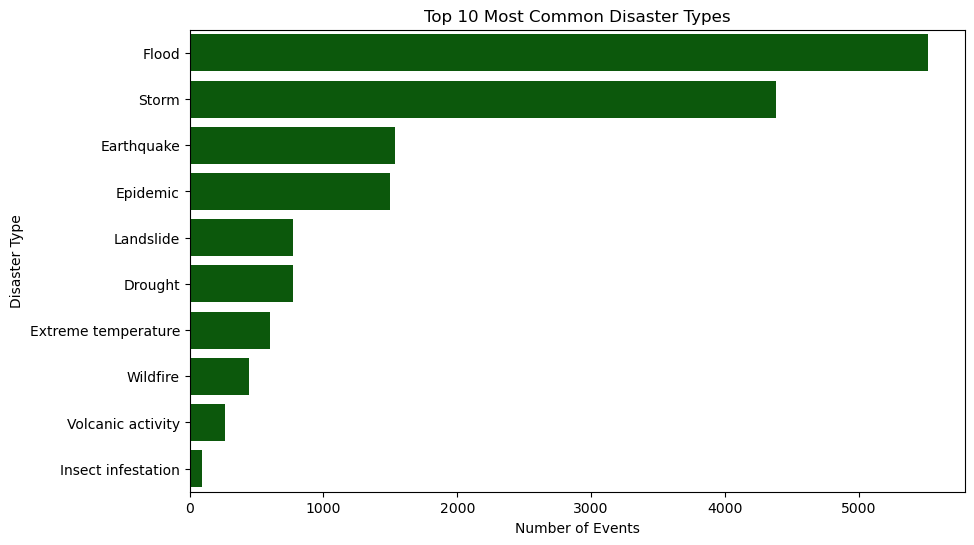

In [91]:
plt.figure(figsize=(10,6))
sns.countplot(
    y='Disaster Type',
    data=df,
    order=df['Disaster Type'].value_counts().head(10).index,
    color='darkgreen'  
)

plt.title('Top 10 Most Common Disaster Types')
plt.xlabel('Number of Events')
plt.ylabel('Disaster Type')
plt.show()

# 2- Top Disaster Types per Country

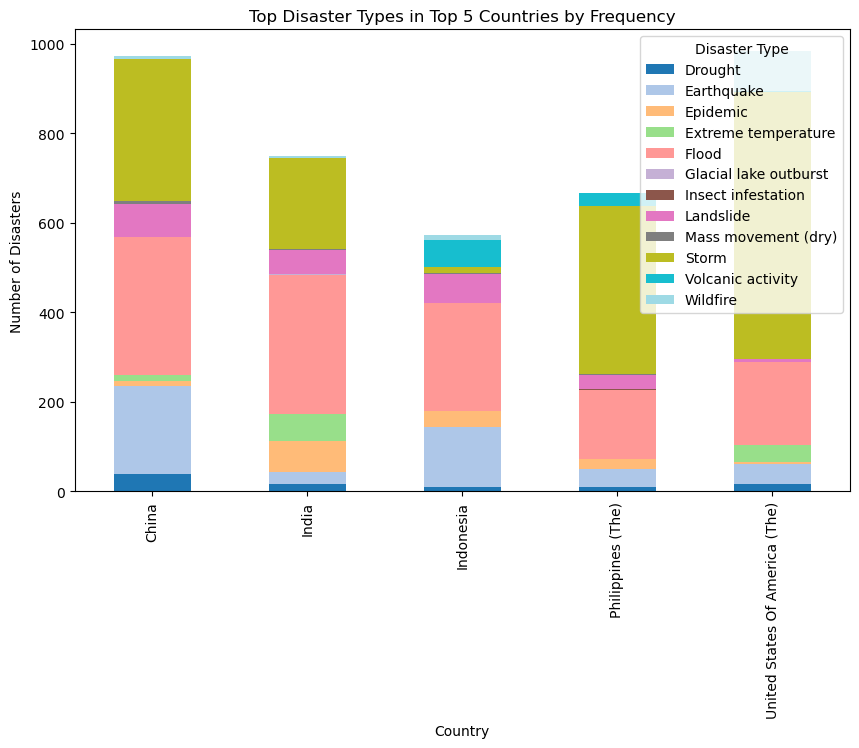

In [92]:
# Top 5 countries with most disasters
top_countries = df['Country'].value_counts().head(5).index
stacked_data = df[df['Country'].isin(top_countries)].groupby(['Country', 'Disaster Type']).size().unstack(fill_value=0)

stacked_data.plot(kind='bar', stacked=True, figsize=(10,6), colormap='tab20')
plt.title('Top Disaster Types in Top 5 Countries by Frequency')
plt.ylabel('Number of Disasters')
plt.xlabel('Country')
plt.show()

# 1️⃣2️⃣ Save Cleaned Data 

In [93]:
df.to_excel("cleaned_disaster_events.xlsx", index=False)